In [1]:
import gcinfo

datasets = gcinfo.search_datasets(query='title:"Permanent Residents – Monthly IRCC Updates"', rows=50)["results"]
dataset = next(item for item in datasets if item["title"] == "Permanent Residents – Monthly IRCC Updates")
gcinfo.list_resources(dataset)



=== Permanent Residents – Monthly IRCC Updates ===
ID: f7e5498e-0ad8-4417-85c9-9b8aff9b9eda
Org: Immigration, Refugees and Citizenship Canada | Immigration, Réfugiés et Citoyenneté Canada
Notes: People who have been granted permanent resident status in Canada.

Please note that in these datasets, the figures have been suppressed or rounded to prevent the identification of individuals when t...
Citation: Immigration, Refugees and Citizenship Canada. Permanent Residents – Monthly IRCC Updates
  [XLSX    ] Canada - Permanent Residents by Province/Territory and Immigration Category
           https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-PR-ProvImmCat.xlsx
  [XLSX    ] Canada - Permanent Residents by Province/Territory and Immigration Category
           https://www.ircc.canada.ca/opendata-donneesouvertes/data/FR_ODP-PR-ProvImmCat.xlsx
  [CSV     ] [rounded - not for calculations] Canada - Permanent resident by province/territory and immigration category
           https

In [2]:
df = gcinfo.download_xlsx("https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-PR-Citz.xlsx")


Using cached file: cache\EN_ODP-PR-Citz.xlsx


In [3]:
import pandas as pd

year_row = df.iloc[1]
quarter_row = df.iloc[2]
month_row = df.iloc[3]
total_row = df.loc[df.iloc[:, 0] == "Total"].iloc[0]

full_months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

records = []
for i, label in enumerate(quarter_row.tolist()):
    if not (isinstance(label, str) and label[:4].isdigit() and label.endswith(" Total")):
        continue
    year = int(label[:4])
    starts = [j for j, value in enumerate(year_row.tolist()) if str(value) == str(year)]
    start = starts[0]
    months_present = [
        str(value) for value in month_row.iloc[start:i + 1].tolist() if pd.notna(value)
    ]
    # The newest year in the file is often only part of the calendar year.
    if not all(month in months_present for month in full_months):
        continue
    admissions = int(str(total_row.iloc[i]).replace(",", "").replace("--", "0"))
    records.append({"Year": year, "Permanent Residents": admissions})

plot_df = pd.DataFrame(records)
plot_df


,Year,Permanent Residents
0,2015,271840
1,2016,296375
2,2017,286540
3,2018,321055
4,2019,341175
5,2020,184605
6,2021,406055
7,2022,437635
8,2023,471820
9,2024,483655


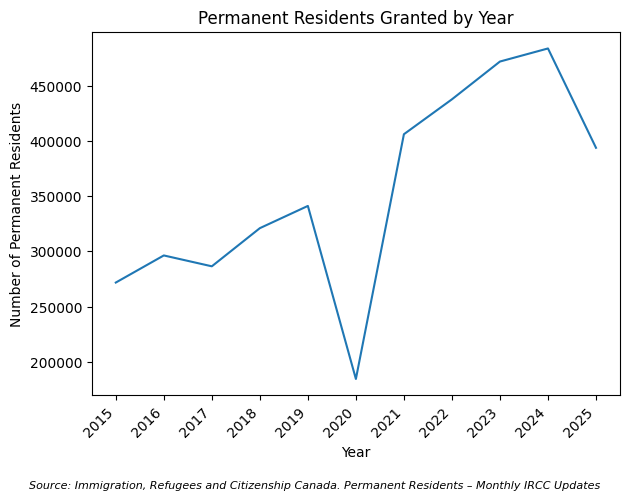

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(plot_df["Year"], plot_df["Permanent Residents"], linestyle="-")
ax.set_xticks(plot_df["Year"].tolist())

ax.set_title("Permanent Residents Granted by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Permanent Residents")

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5, -0.03,
    "Source: Immigration, Refugees and Citizenship Canada. Permanent Residents – Monthly IRCC Updates",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()
